# Manuscript Transmission: Agent-Based Models and Bayesian Inference

#### Jean-Baptiste Camps, Ulysse Godreau, and Théo Moins

---

**Overview.** This notebook introduces how *agent-based models* (ABMs) can simulate the historical transmission of medieval texts, and how *Simulation-Based Inference* (SBI) can recover the hidden parameters that governed that process.

We work with **abundance data**: for each text in a tradition, we observe *how many surviving witnesses* (manuscript copies) exist today — but we do not know the genealogical tree (stemma) that connects them.

**What you will learn:**

1. How to set up and configure a simulation experiment with `simmatree`
2. How a **Birth-Death** model (2 parameters) generates abundance data
3. How a **Yule** model (4 parameters) generates richer dynamics
4. How to run **SBI inference** to recover model parameters from observed data
5. How to evaluate inference quality and apply it to **real manuscript data**



## 0. Installation and Setup

`simmatree` can be installed directly from GitHub. On Google Colab, we install without dependencies first to avoid conflicts, then install the required packages separately.


In [75]:
# Install simmatree from GitHub
# !pip install git+https://github.com/LostMa-ERC/simMAtree.git --no-deps -q
# !pip install pandas numpy matplotlib seaborn pydantic click rich pyyaml sbi torch -q

# Verify installation
!simmatree-test

Looks good!


In [76]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# simmatree imports
from src.cli.config import Config
from src.cli.generate import generate
from src.cli.inference import inference
from src.cli.score import score

# Working directory
WORK_DIR = Path("./")
WORK_DIR.mkdir(exist_ok=True)

print("All imports successful!")

All imports successful!


## 1. What Are Abundance Data?

In textual scholarship, a **text** (or *work*) may survive through multiple **witnesses** (manuscript copies).

**Abundance data** is simply the count of surviving witnesses per text across a corpus:

| Text | Witnesses |
|------|-----------|
| Text A | 12 |
| Text B | 1 |
| Text C | 3 |
| ... | ... |

This kind of data is easy to collect — you just need a catalogue — and it contains rich information about the *dynamics* of manuscript production and destruction.

The key insight is that the **distribution** of these counts (many texts with 1 copy, fewer with 2, very few with dozens) follows patterns that depend on the underlying copying and destruction rates. If we can simulate these processes, we can *infer* those rates from real data.


## 2. Configuring a Simulation Experiment

`simmatree` uses a YAML configuration file with the following blocks:

| Block | Purpose |
|-------|---------|
| `generator` | Which simulation model to use and its structural settings |
| `stats` | Which summary statistics to extract from simulated data |
| `prior` | The prior distribution on model parameters (for inference) |
| `params` | Ground-truth parameter values (for generation and evaluation) |
| `inference` | SBI backend configuration (method, number of simulations, etc.) |

Let's start with the simplest model: **Birth-Death**.


## 3. The Birth-Death Model (2 Parameters)

The Birth-Death model is the simplest transmission model. It has two parameters:

- **Λ (LDA)**: the *innovation rate* — rate at which new independent texts appear
- **λ (lda)**: the *birth rate* — probability that a manuscript is copied at each time step
- **μ (mu)**: the *death rate* — probability that a manuscript is destroyed at each time step

The simulation runs in two phases:
1. **Active phase** (`Nact` steps): both copying and destruction occur
2. **Inactive phase** (`Ninact` steps): only destruction occurs (no new copies are made)

This mirrors the historical reality: texts were actively copied for a period, then interest waned, but manuscripts continued to be lost over time.


### 3.1 Configuration

We define the full configuration dictionary, including all five blocks required by `simmatree`.

> **Note:** The `prior` block defines the range of parameter values that the inference engine will explore. The `prior` and `stats` blocks are **required** for inference — omitting them was the source of errors in previous versions of this tutorial.


In [77]:
# ── Birth-Death configuration ──────────────────────────────────────────

config_dict_BD = {

    # --- Simulator ---
    "generator": {
        "name": "BirthDeathAbundance",
        "config": {
            "n_init": 110,      # Number of independent texts (trees)
            "Nact": 1000,       # Active transmission phase (time steps)
            "Ninact": 1000,     # Inactive phase: only destruction
            "max_pop": 50000,   # Safety cap to prevent memory overflow
        },
    },

    # --- Summary statistics extracted from simulated data ---
    "stats": {
        "name": "Abundance",
        "config": {
            "additional_stats": True,  # Include extra distributional stats
        },
    },

    # --- Prior distribution on (lda, mu) ---
    "prior": {
        "name": "ConstrainedUniform3D",
        "config": {
            "low": [0.0, 0.0, 0.0],
            "high": [1.0, 0.015, 0.01],
        },
    },

    # --- Ground truth parameters (for generation & scoring) ---
    "params": {
        "LDA": 0.3,
        "lda": 0.009,
        "mu": 0.0033,
    },
    # --- SBI inference settings ---
    "inference": {
        "name": "SBI",
        "config": {
            "method": "NPE",            # Neural Posterior Estimation
            "num_simulations": 200,      # Fast for demo; increase for real work
            "num_rounds": 1,
            "random_seed": 42,
            "num_samples": 200,
            "num_workers": 2,
            "device": "cpu",
        },
    },
}

# Save to YAML and parse with simmatree's Config class
config_file_BD = WORK_DIR / "config_BD.yml"
with open(config_file_BD, "w") as f:
    yaml.dump(config_dict_BD, f, default_flow_style=False)

config_BD = Config(str(config_file_BD))

print("Configuration parsed successfully!")
print(f"Generator: {type(config_BD.generator).__name__}")
print(f"Prior dimension: {config_BD.prior.dimension if hasattr(config_BD.prior, 'dimension') else '?'}")

Configuration parsed successfully!
Generator: BirthDeathAbundance
Prior dimension: 3


### 3.2 Generating Synthetic Abundance Data

We now simulate the Birth-Death process with known parameters. This produces a CSV file listing each surviving witness and the text it belongs to.


In [78]:
# Generate synthetic data
data_file_BD = str(WORK_DIR / "synthetic_BD.csv")

generate(
    data_path=data_file_BD,
    generator=config_BD.generator,
    parameters=config_BD.params,
    stats=config_BD.stats,
    seed=42,
    show_params=False,
)

print(f"\nCLI equivalent:")
print(f"  simmatree -c {config_file_BD} generate -o {data_file_BD}")

Generating population...

Number of witnesses: 1554
Number of texts: 157
Max. number of witnesses per text: 59
Med. number of witnesses per text: 4
Number of text with one witness: 44

Done!

CLI equivalent:
  simmatree -c config_BD.yml generate -o synthetic_BD.csv


### 3.3 Exploring the Generated Data

Let's look at the raw data and its distribution.

In [79]:
# Load and inspect the generated data
df_BD = pd.read_csv(data_file_BD, sep=";")

print("First 10 rows:")
print(df_BD.head(10))
print(f"\nTotal witnesses: {len(df_BD)}")
print(f"Total texts: {df_BD['text_ID'].nunique()}")

First 10 rows:
  witness_ID text_ID
0       W0-1      T0
1       W0-2      T0
2       W0-3      T0
3       W0-4      T0
4       W0-5      T0
5       W0-6      T0
6       W0-7      T0
7       W0-8      T0
8       W0-9      T0
9      W0-10      T0

Total witnesses: 1554
Total texts: 157


In [80]:
# Compute witness counts per text
witness_counts_BD = df_BD.groupby("text_ID")["witness_ID"].count()

print(f"Mean witnesses per text:   {witness_counts_BD.mean():.2f}")
print(f"Median witnesses per text: {witness_counts_BD.median():.1f}")
print(f"Max witnesses for a text:  {witness_counts_BD.max()}")
print(f"Texts with only 1 witness: {(witness_counts_BD == 1).sum()}")

Mean witnesses per text:   9.90
Median witnesses per text: 4.0
Max witnesses for a text:  59
Texts with only 1 witness: 45


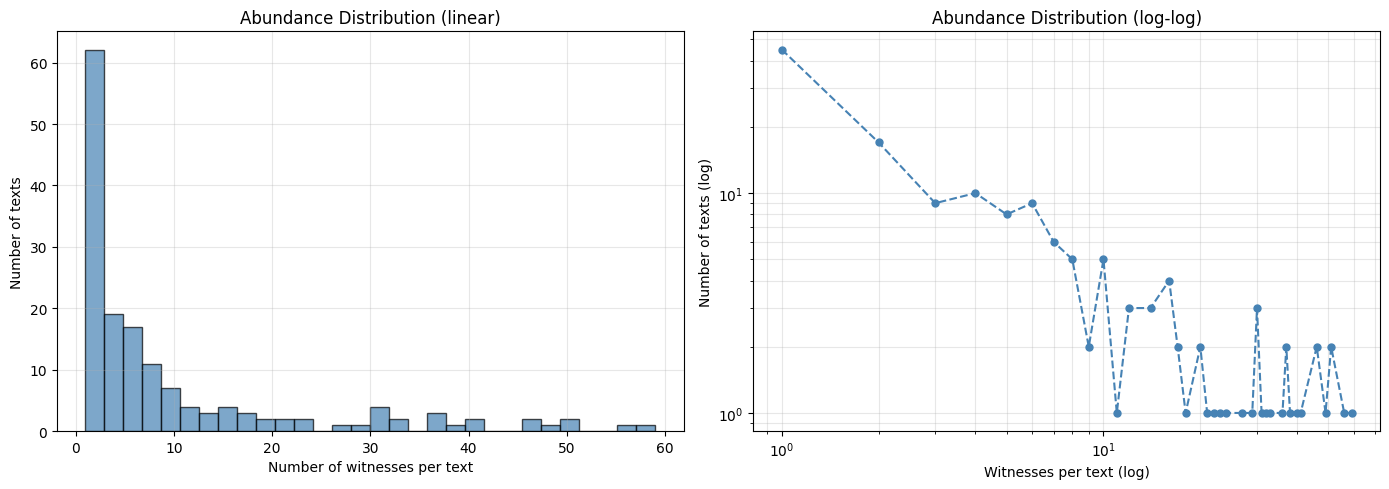

In [81]:
# Visualize the abundance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(witness_counts_BD, bins=30, alpha=0.7, edgecolor="black", color="steelblue")
axes[0].set_xlabel("Number of witnesses per text")
axes[0].set_ylabel("Number of texts")
axes[0].set_title("Abundance Distribution (linear)")
axes[0].grid(True, alpha=0.3)

# Log-log scale — typical for heavy-tailed distributions
freq = witness_counts_BD.value_counts().sort_index()
axes[1].plot(freq.index, freq.values, "o--", markersize=5, color="steelblue")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Witnesses per text (log)")
axes[1].set_ylabel("Number of texts (log)")
axes[1].set_title("Abundance Distribution (log-log)")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

### 3.4 Running SBI Inference on Birth-Death Data

Now comes the core step: given the observed abundance data, can we **recover** the parameters (λ, μ) that generated it?

We use **Neural Posterior Estimation (NPE)**: a neural network is trained on many simulated (parameter, data) pairs, and then used to approximate the posterior distribution p(θ | x_obs).

> **Important:** The `inference()` function requires `generator`, `stats`, `prior`, and `backend` — all four components.


In [82]:
# Run SBI inference
results_dir_BD = WORK_DIR / "results_BD"
results_dir_BD.mkdir(exist_ok=True)

inference_data_BD = inference(
    csv_file=data_file_BD,
    generator=config_BD.generator,
    stats=config_BD.stats,
    prior=config_BD.prior,
    backend=config_BD.backend,
    dir=results_dir_BD,
    csv_separator=";",
)

print(f"\nGenerated files: {[f.name for f in results_dir_BD.glob('*')]}")
print(f"\nCLI equivalent:")
print(f"  simmatree -c {config_file_BD} infer -i {data_file_BD} -o {results_dir_BD}")

───────────────────────────────────────────────────── Dataset ─────────────────────────────────────────────────────

Data: synthetic_BD.csv

──────────────────────────────────────────────── Running inference ────────────────────────────────────────────────

BirthDeathAbundance

Training device: cpu
Running simulations...
ROUND 1


...

Running posterior predictive checks...


100%|██████████| 200/200 [00:37<00:00,  5.32it/s]


───────────────────────────────────────────────── Writing results ─────────────────────────────────────────────────

Output directory:  /home/tmoins/Documents/witness_distribution/simMAtree/results_BD

1 outlier values excluded (>100000)

Generated files: ['richness_summary.csv', 'survival_rates_summary.csv', 'posterior_summary.csv', 'survival_rates_posterior.png', 'prior_posterior_comparison.png', 'posterior_samples.npy', 'pp_summaries.png', 'posterior_predictive.npy', 'pairplot.png', 'summary_metrics.csv', 'obs_values.npy', 'posterior.png', 'relative_error.png', 'richness_posterior.png']

CLI equivalent:
  simmatree -c config_BD.yml infer -i synthetic_BD.csv -o results_BD


### 3.5 Examining Inference Results

`simmatree` produces several outputs:
- **Posterior summary** (CSV): mean, median, HPDI for each parameter
- **Posterior plot**: marginal distributions for each parameter
- **Pairplot**: joint posterior showing correlations between parameters
- **Posterior predictive checks**: does data simulated from the posterior look like the observed data?


In [83]:
# Load and display posterior summary
posterior_summary_BD = pd.read_csv(results_dir_BD / "posterior_summary.csv")
print("Posterior Summary:")
print(posterior_summary_BD.round(6))

# Compare with ground truth
true_params_BD = config_BD.params
param_names_BD = [k for k, v in true_params_BD.items() if v is not None]

print(f"\n{'Parameter':<10} {'True':>10} {'HPDI point':>12} {'Rel. Error':>12}")
print("-" * 46)
for i, name in enumerate(param_names_BD):
    true_val = true_params_BD[name]
    est_val = posterior_summary_BD["hpdi_95%"].values[i]
    err = abs(est_val - true_val) / true_val * 100
    print(f"{name:<10} {true_val:>10.6f} {est_val:>12.6f} {err:>10.1f}%")

Posterior Summary:
   Unnamed: 0      mean      std        5%       50%       95%  hpdi_95%
0           0  0.509234  0.22697  0.125139  0.508469  0.879121  0.517733
1           1  0.006480  0.00191  0.003717  0.006338  0.009921  0.006161
2           2  0.002167  0.00115  0.000549  0.002080  0.004346  0.001966

Parameter        True   HPDI point   Rel. Error
----------------------------------------------
LDA          0.300000     0.517733       72.6%
lda          0.009000     0.006161       31.5%
mu           0.003300     0.001966       40.4%


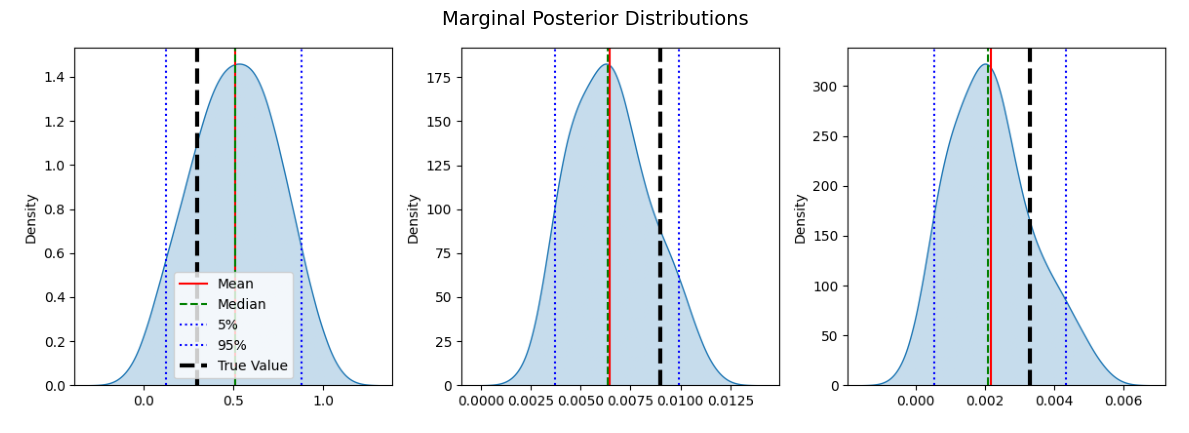

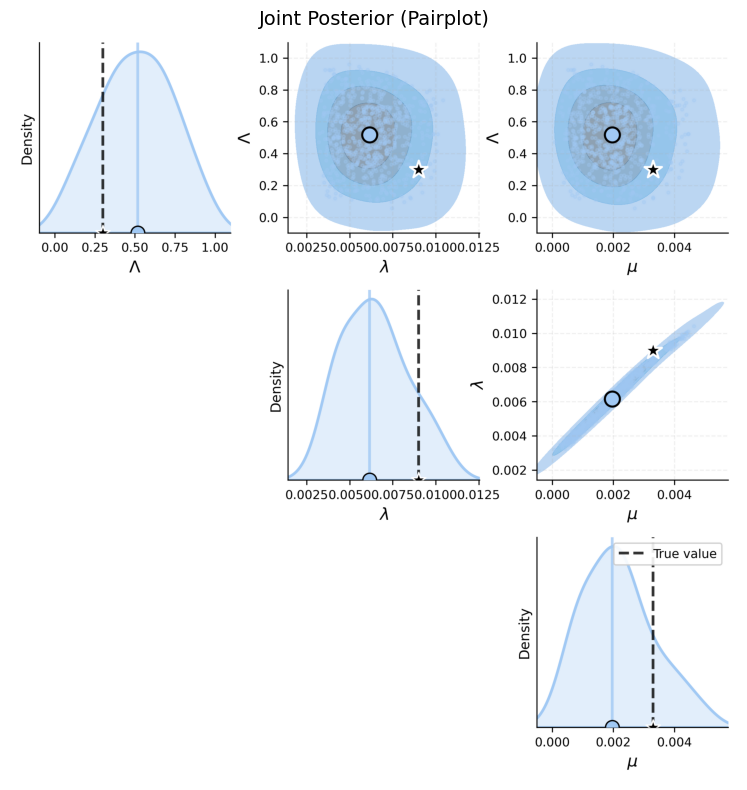

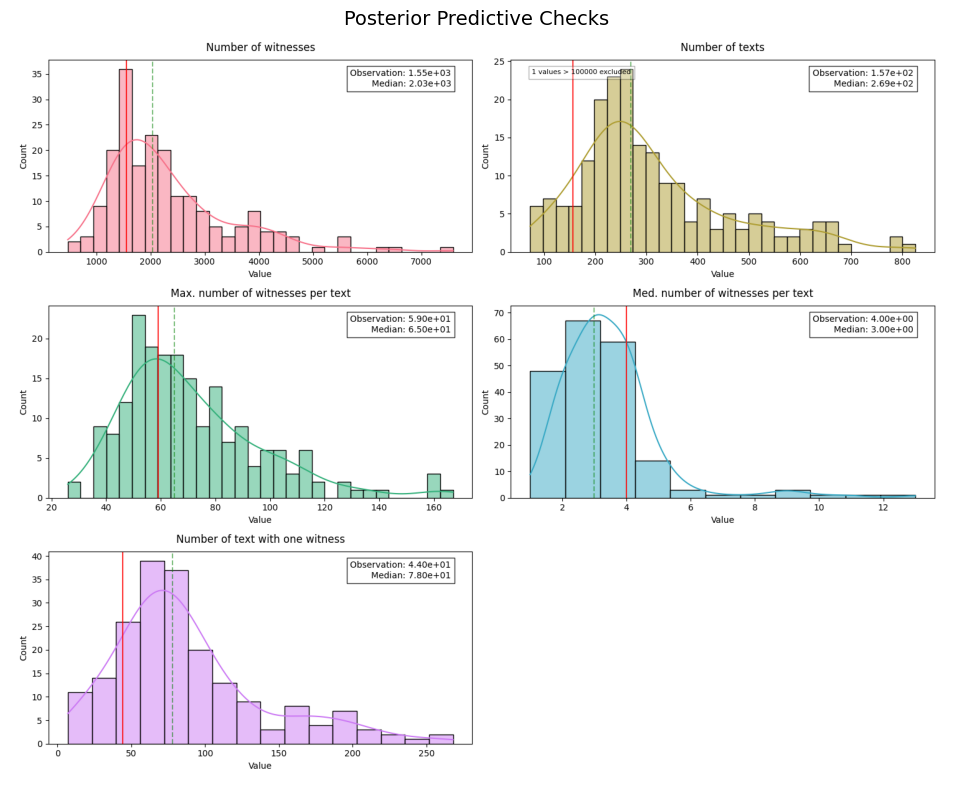

In [96]:
# Display diagnostic plots
import matplotlib.image as mpimg

plot_files = [
    ("posterior.png", "Marginal Posterior Distributions"),
    ("pairplot.png", "Joint Posterior (Pairplot)"),
    ("pp_summaries.png", "Posterior Predictive Checks"),
]

for filename, title in plot_files:
    path = results_dir_BD / filename
    if path.exists():
        img = mpimg.imread(str(path))
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=14)
        plt.tight_layout()
        plt.show()

### 3.6 Evaluating Inference Quality

Since we know the true parameters, we can evaluate how well the inference performed using metrics like RMSE, coverage probability, and relative error.


In [85]:
# Score the inference results against ground truth
score(
    param_dict=config_BD.params,
    results_dir=str(results_dir_BD),
)

# Load and display metrics
metrics_file = results_dir_BD / "summary_metrics.csv"
if metrics_file.exists():
    metrics_BD = pd.read_csv(metrics_file)
    print("\nEvaluation Metrics:")
    print(metrics_BD.round(6))

print(f"\nCLI equivalent:")
print(f"  simmatree -c {config_file_BD} score -d {results_dir_BD}")

1 outlier values excluded (>100000)

=== Summary of Evaluation Metrics ===
rmse: 0.12572096523075488
nrmse: 0.5130922055786334
mean_rel_error_pct: 48.18733865319865
coverage_probability: 1.0

=== Parameter-Specific Metrics ===

LDA:
  true_value: 0.3
  hpdi_point: 0.5177325
  post. mean: 0.5092344
  rel_error_pct: 72.57750000000001
  norm_squared_error: 0.5267493506250003
  bias: 0.21773250000000005
  hpdi_interval: (0.08170454949140549, 0.9245234966278076)
  in_hpdi_95: True

lda:
  true_value: 0.009
  hpdi_point: 0.0061608152
  post. mean: 0.006479808
  rel_error_pct: 31.54649777777777
  norm_squared_error: 0.09951815220433378
  bias: -0.002839184799999999
  hpdi_interval: (0.0035083173017483203, 0.01052123475819826)
  in_hpdi_95: True

mu:
  true_value: 0.0033
  hpdi_point: 0.0019655454
  post. mean: 0.0021673825
  rel_error_pct: 40.43801818181818
  norm_squared_error: 0.16352333144730577
  bias: -0.0013344545999999999
  hpdi_interval: (0.0004004901202279143, 0.004758089932147412)
 

## 4. The Yule Model (4 Parameters)

The Yule model extends Birth-Death with two additional processes:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `LDA` (Λ) | Innovation rate | Rate at which entirely *new* texts appear |
| `lda` (λ) | Copying rate | Rate at which existing manuscripts are copied |
| `gamma` (γ) | Speciation rate | Rate at which a copy diverges enough to become a new "text" |
| `mu` (μ) | Death rate | Rate at which manuscripts are destroyed |

This model is richer because it can generate the **number of distinct texts** as an emergent property, not just as a fixed input (`n_init`).

> With the Yule model, we typically start with `n_init=1` (a single archetype) and let the simulation generate new texts through the speciation process.


In [86]:
# ── Yule configuration ─────────────────────────────────────────────────

config_dict_Yule = {
    "generator": {
        "name": "YuleAbundance",
        "config": {
            "n_init": 1,
            "Nact": 1000,
            "Ninact": 1000,
            "max_pop": 50000,
        },
    },

    "stats": {
        "name": "Abundance",
        "config": {"additional_stats": True},
    },

    "prior": {
        "name": "ConstrainedUniform4D",
        "config": {
            "low": [0.0, 0.0, 0.0, 0.0],
            "high": [1.0, 0.015, 0.01, 0.01],
        },
    },

    "params": {
        "LDA": 0.3,
        "lda": 0.009,
        "gamma": 0.001,
        "mu": 0.0033,
    },

    "inference": {
        "name": "SBI",
        "config": {
            "method": "NPE",
            "num_simulations": 200,
            "num_rounds": 1,
            "random_seed": 42,
            "num_samples": 200,
            "num_workers": 2,
            "device": "cpu",
        },
    },
}

config_file_Yule = WORK_DIR / "config_Yule.yml"
with open(config_file_Yule, "w") as f:
    yaml.dump(config_dict_Yule, f, default_flow_style=False)

config_Yule = Config(str(config_file_Yule))
print("Yule configuration parsed successfully!")

Yule configuration parsed successfully!


### 4.1 Generate and Visualize Yule Data

In [87]:
# Generate Yule abundance data
data_file_Yule = str(WORK_DIR / "synthetic_Yule.csv")

generate(
    data_path=data_file_Yule,
    generator=config_Yule.generator,
    parameters=config_Yule.params,
    stats=config_Yule.stats,
    seed=42,
)

Generating population...

Number of witnesses: 1594
Number of texts: 720
Max. number of witnesses per text: 42
Med. number of witnesses per text: 1
Number of text with one witness: 520

Done!


True

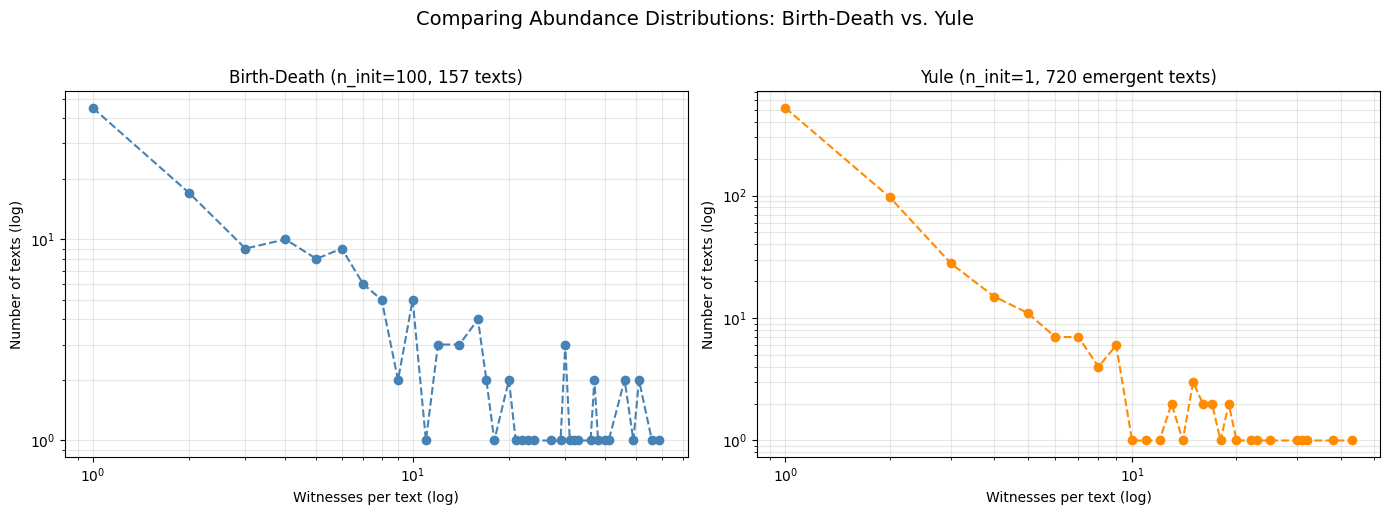

Birth-Death: 157 texts, 1554 total witnesses
Yule:        720 texts, 1594 total witnesses


In [88]:
# Compare Birth-Death vs Yule distributions side by side
df_Yule = pd.read_csv(data_file_Yule, sep=";")
wc_Yule = df_Yule.groupby("text_ID")["witness_ID"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Birth-Death
freq_BD = witness_counts_BD.value_counts().sort_index()
axes[0].plot(freq_BD.index, freq_BD.values, "o--", color="steelblue", label="Birth-Death")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Witnesses per text (log)")
axes[0].set_ylabel("Number of texts (log)")
axes[0].set_title(f"Birth-Death (n_init=100, {len(witness_counts_BD)} texts)")
axes[0].grid(True, alpha=0.3, which="both")

# Yule
freq_Yule = wc_Yule.value_counts().sort_index()
axes[1].plot(freq_Yule.index, freq_Yule.values, "o--", color="darkorange", label="Yule")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Witnesses per text (log)")
axes[1].set_ylabel("Number of texts (log)")
axes[1].set_title(f"Yule (n_init=1, {len(wc_Yule)} emergent texts)")
axes[1].grid(True, alpha=0.3, which="both")

plt.suptitle("Comparing Abundance Distributions: Birth-Death vs. Yule", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Birth-Death: {len(witness_counts_BD)} texts, {len(df_BD)} total witnesses")
print(f"Yule:        {len(wc_Yule)} texts, {len(df_Yule)} total witnesses")

### 4.2 Inference on Yule Data

With 4 parameters, the inference task is more challenging. The posterior will be 4-dimensional, and we may see correlations between parameters (e.g., higher birth rate compensated by higher death rate).


In [89]:
# Run inference on Yule data
results_dir_Yule = WORK_DIR / "results_Yule"
results_dir_Yule.mkdir(exist_ok=True)

inference_data_Yule = inference(
    csv_file=data_file_Yule,
    generator=config_Yule.generator,
    stats=config_Yule.stats,
    prior=config_Yule.prior,
    backend=config_Yule.backend,
    dir=results_dir_Yule,
    csv_separator=";",
)

───────────────────────────────────────────────────── Dataset ─────────────────────────────────────────────────────

Data: synthetic_Yule.csv

──────────────────────────────────────────────── Running inference ────────────────────────────────────────────────

YuleAbundance

Training device: cpu
Running simulations...
ROUND 1


...

Running posterior predictive checks...


100%|██████████| 200/200 [01:51<00:00,  1.79it/s]


───────────────────────────────────────────────── Writing results ─────────────────────────────────────────────────

Output directory:  /home/tmoins/Documents/witness_distribution/simMAtree/results_Yule

12 outlier values excluded (>100000)


In [90]:
# Display Yule posterior summary
posterior_summary_Yule = pd.read_csv(results_dir_Yule / "posterior_summary.csv")
print("Yule Posterior Summary:")
print(posterior_summary_Yule.round(6))

# Compare with ground truth
true_params_Yule = config_Yule.params
param_names_Yule = [k for k, v in true_params_Yule.items() if v is not None]

print(f"\n{'Parameter':<10} {'True':>10} {'HPDI point':>12} {'Rel. Error':>12}")
print("-" * 46)
for i, name in enumerate(param_names_Yule):
    true_val = true_params_Yule[name]
    est_val = posterior_summary_Yule["hpdi_95%"].values[i]
    err = abs(est_val - true_val) / true_val * 100
    print(f"{name:<10} {true_val:>10.6f} {est_val:>12.6f} {err:>10.1f}%")

Yule Posterior Summary:
   Unnamed: 0      mean       std        5%       50%       95%  hpdi_95%
0           0  0.344381  0.167179  0.094597  0.320249  0.656706  0.323012
1           1  0.006285  0.001802  0.003604  0.006148  0.009718  0.006086
2           2  0.001180  0.000605  0.000243  0.001162  0.002220  0.001147
3           3  0.001979  0.000811  0.000765  0.001933  0.003562  0.001903

Parameter        True   HPDI point   Rel. Error
----------------------------------------------
LDA          0.300000     0.323012        7.7%
lda          0.009000     0.006086       32.4%
gamma        0.001000     0.001147       14.7%
mu           0.003300     0.001903       42.3%


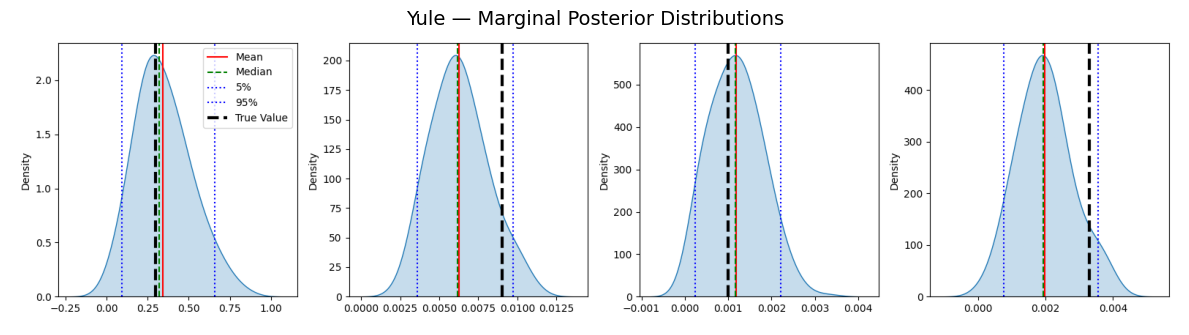

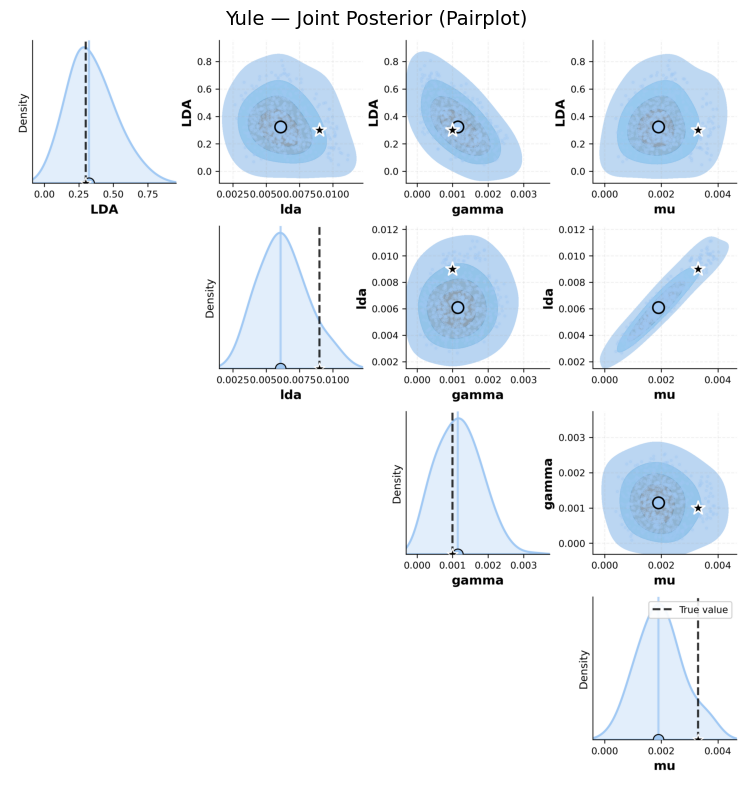

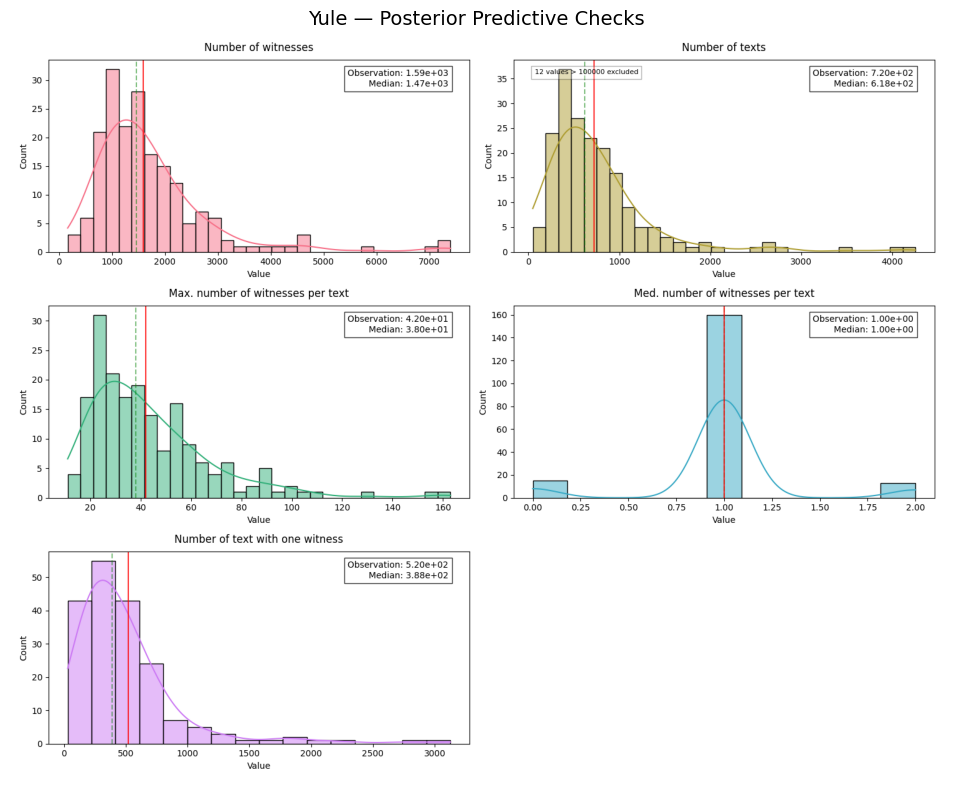

In [95]:
# Display Yule diagnostic plots
for filename, title in plot_files:
    path = results_dir_Yule / filename
    if path.exists():
        img = mpimg.imread(str(path))
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Yule — {title}", fontsize=14)
        plt.tight_layout()
        plt.show()

In [92]:
# Score Yule inference
score(param_dict=config_Yule.params, results_dir=str(results_dir_Yule))

metrics_file_Yule = results_dir_Yule / "summary_metrics.csv"
if metrics_file_Yule.exists():
    metrics_Yule = pd.read_csv(metrics_file_Yule)
    print("\nYule Evaluation Metrics:")
    print(metrics_Yule.round(6))

12 outlier values excluded (>100000)

=== Summary of Evaluation Metrics ===
rmse: 0.01161924028641598
nrmse: 0.2790907357238179
mean_rel_error_pct: 24.278616717171715
coverage_probability: 1.0

=== Parameter-Specific Metrics ===

LDA:
  true_value: 0.3
  hpdi_point: 0.3230122
  post. mean: 0.34438077
  rel_error_pct: 7.670733333333346
  norm_squared_error: 0.005884014987111131
  bias: 0.023012200000000038
  hpdi_interval: (0.06267915116623045, 0.7108531653881072)
  in_hpdi_95: True

lda:
  true_value: 0.009
  hpdi_point: 0.006085616
  post. mean: 0.006284683
  rel_error_pct: 32.38204444444443
  norm_squared_error: 0.10485968024019747
  bias: -0.002914383999999999
  hpdi_interval: (0.0032646271341945977, 0.010130372876301407)
  in_hpdi_95: True

gamma:
  true_value: 0.001
  hpdi_point: 0.0011474298
  post. mean: 0.0011795481
  rel_error_pct: 14.742979999999998
  norm_squared_error: 0.021735545928039994
  bias: 0.00014742979999999998
  hpdi_interval: (0.0001504963143815985, 0.00238962551

## 5. What Happens with the Wrong Model?

An important question in practice: what if we use the **wrong model** for inference?

Here we generate data with the **Yule** model (4 parameters) but run inference with the **Birth-Death** model (2 parameters). This is called **model misspecification**.

We might expect the Birth-Death model to partially capture the dynamics (λ, μ) but miss the innovation and speciation processes — leading to biased estimates.


In [93]:
# Run Birth-Death inference on Yule-generated data
results_dir_misspec = WORK_DIR / "results_misspecified"
results_dir_misspec.mkdir(exist_ok=True)

inference_data_misspec = inference(
    csv_file=data_file_Yule,           # <-- Yule data
    generator=config_BD.generator,     # <-- Birth-Death model
    stats=config_BD.stats,
    prior=config_BD.prior,
    backend=config_BD.backend,
    dir=results_dir_misspec,
    csv_separator=";",
)

# Display results
posterior_misspec = pd.read_csv(results_dir_misspec / "posterior_summary.csv")
print("Misspecified Inference (BD model on Yule data):")
print(posterior_misspec.round(6))

───────────────────────────────────────────────────── Dataset ─────────────────────────────────────────────────────

Data: synthetic_Yule.csv

──────────────────────────────────────────────── Running inference ────────────────────────────────────────────────

BirthDeathAbundance

Training device: cpu
Running simulations...
ROUND 1


...

Running posterior predictive checks...


100%|██████████| 200/200 [00:31<00:00,  6.28it/s]


───────────────────────────────────────────────── Writing results ─────────────────────────────────────────────────

Output directory:  /home/tmoins/Documents/witness_distribution/simMAtree/results_misspecified

11 outlier values excluded (>100000)
Misspecified Inference (BD model on Yule data):
   Unnamed: 0      mean       std        5%       50%       95%  hpdi_95%
0           0  0.568713  0.215388  0.186990  0.580602  0.908313  0.597445
1           1  0.006053  0.002088  0.002506  0.005939  0.010118  0.005891
2           2  0.002667  0.001083  0.000812  0.002608  0.004763  0.002587


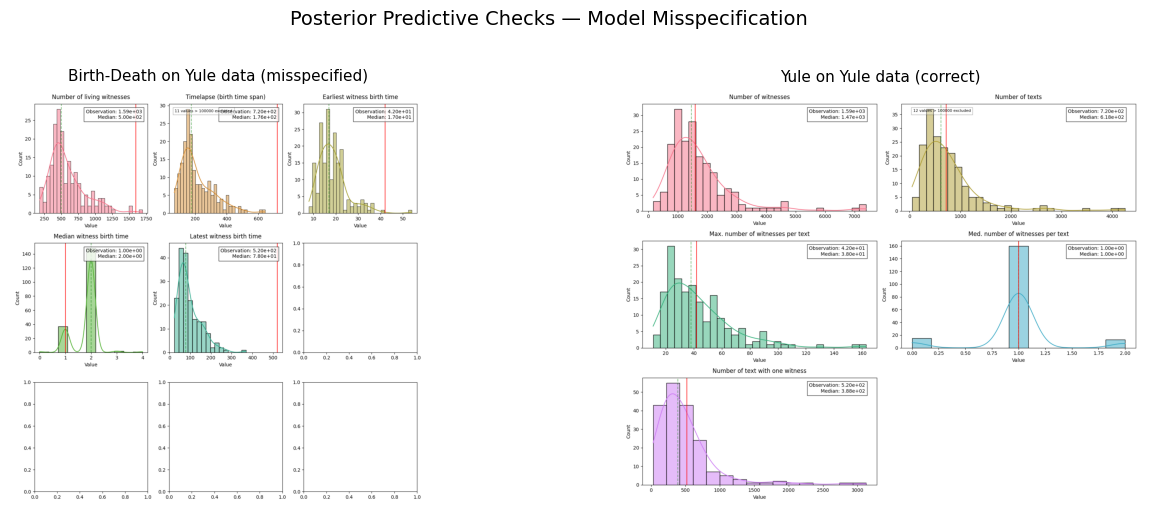

In [94]:
# Compare posterior predictive checks: misspecified vs correct model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (rdir, label) in zip(axes, [
    (results_dir_misspec, "Birth-Death on Yule data (misspecified)"),
    (results_dir_Yule, "Yule on Yule data (correct)"),
]):
    pp_path = rdir / "pp_summaries.png"
    if pp_path.exists():
        img = mpimg.imread(str(pp_path))
        ax.imshow(img)
        ax.set_title(label, fontsize=11)
    ax.axis("off")

plt.suptitle("Posterior Predictive Checks — Model Misspecification", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Takeaway:** Posterior predictive checks are essential. Even if a model produces tight posteriors, checking whether simulated data from those posteriors *looks like* the observed data reveals misspecification.

> This motivates **model comparison** techniques, which we will explore in Part 2 using stemma-based summary statistics.


---

*Funded by the European Union (ERC, LostMA, 101117408). Views and opinions expressed are those of the author(s) only and do not necessarily reflect those of the European Union or the European Research Council.*
